This is the code for the data cleaning, wrangling, word2vec model creation, and some data visualizations.

In [237]:
# import impportant libraries
import pandas as pd
import numpy as np
import ast
import re, string
import json
import csv
import bs4
from bs4 import BeautifulSoup
import requests
import time
import random
from tqdm import tqdm
import spacy
import gensim
import nltk
from nltk.probability import FreqDist
from nltk.corpus import stopwords
import wordcloud 
# ! python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

# data viz
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap as LSC
import seaborn as sns
import sklearn.manifold #For T-SNE
import sklearn.decomposition #For PCA

In [241]:
# create a regular expression for removing non-english characters
nonenglish_comms = r"""[^a-zA-Z\d\s\[\]\-\#\.\?\,\&\<\>\!\@\$\%\^\*\+\=\:\;\\/\%\'\"]"""
stop_words = stopwords.words('english') 

# create custom color map for graphs
colors = ['#800000', '#D9D9D9', '#A6A6A6', '#737373']
cmap = LSC.from_list("custom_colormap", colors)

### Helper funcs from other classes

In [4]:
# function from HW2 and HW4 of Content Analysis

def word_tokenize(word_list):
    """
    Take a list of words and tokenize the text
    Input: list of strs
    Returns a list of tokenized strs 
    """
    tokenized = []
    # pass word list through language model.
    doc = nlp(word_list)
    for token in doc:
        if not token.is_punct and len(token.text.strip()) > 0:
            tokenized.append(token.text)
    return tokenized


def normalizeTokens(word_list, extra_stop=[]):
    """
    Takes a list of words and normalizes the tokens
    Inputs:
        word_list: list of strs for words needed to be tokenized
        extra_stop: list of strs for extra stop words
    Returns list of tokenized strs
    """
    #We can use a generator here as we just need to iterate over it
    normalized = []
    if type(word_list) == list and len(word_list) == 1:
        word_list = word_list[0]

    if type(word_list) == list:
        word_list = ' '.join([str(elem) for elem in word_list])

    doc = nlp(word_list.lower())

    # add the property of stop word to words considered as stop words
    if len(extra_stop) > 0:
        for stopword in extra_stop:
            lexeme = nlp.vocab[stopword]
            lexeme.is_stop = True

    for w in doc:
        # if it's not a stop word or punctuation mark, add it to our article
        if w.text != '\n' and not w.is_stop and not w.is_punct \
            and not w.like_num and len(w.text.strip()) > 0:
            # we add the lematized version of the word
            normalized.append(str(w.lemma_))

    return normalized


def sent_tokenize(word_list, model=nlp):
    doc = model(word_list)
    sentences = [sent.text.strip() for sent in doc.sents]
    return sentences


# EDITED
# functions from TextClassification.ipynb MACS 30100

def decontracted(phrase):
    """
    Expand the contracted phrase into normal words
    """
    # specific
    phrase = re.sub(r"won't", "will not", phrase)
    phrase = re.sub(r"can\'t", "can not", phrase)
    # general
    phrase = re.sub(r"n\'t", " not", phrase)
    phrase = re.sub(r"\'re", " are", phrase)
    # doesnt discern between possessive and is, which is future problem
    phrase = re.sub(r"\'s", " is", phrase)
    phrase = re.sub(r"\'d", " would", phrase)
    phrase = re.sub(r"\'ll", " will", phrase)
    phrase = re.sub(r"\'t", " not", phrase)
    phrase = re.sub(r"\'ve", " have", phrase)
    phrase = re.sub(r"\'m", " am", phrase)
    
    return phrase


def tag_sents_pos(sentences):
    """
    function which replicates NLTK pos tagging on sentences.
    """
    new_sents = []
    for sentence in sentences:
        new_sent = ' '.join(sentence)
        new_sents.append(new_sent)
    final_string = ' '.join(new_sents)
    doc = nlp(final_string)

    pos_sents = []
    for sent in doc.sents:
        pos_sent = []
        for token in sent:
            pos_sent.append((token.text, token.tag_))
        pos_sents.append(pos_sent)

    return pos_sents

### My helpers

In [5]:
def clean_transcript(transcript):
    """
    Takes a string that contains a transcript and removes extraneous noise,
    Including timestamps, CC information, etc, some other weird.
    Inputs:
        transcript: str
    Returns a cleaned transcript with text in lower case
    """

    # if auto generated in Arabic it would be much harder to perform our
    # task, so for simplicity we will remove such transcripts
    if re.search(r"Arabic \(auto-generated\)$", transcript):
        return []
    
    # speaker attrs are formatted as ">> [speaker]: " or "12:34:56 [speaker]: "
    speaker = r">>\s*([\w]+):|(?<=\d{2}\s)(\w+)(?=\:)"
    # find the noise in the text, formatting things mostly
    noise = r"(>{1,2}|♪|\b(\d{1,2}\:)*\d{1,2}\:\d{2}\b)"
    # find the transcript formatting things that appear at the end
    cc = r"(?:English \(auto-generated\)|English|English \- cc1)\s*$"
    
    # remove artifacts of being closed captioning: speaker attr, timestamps, etc
    transcript = re.sub(speaker, "", transcript, flags=re.IGNORECASE)
    transcript = re.sub(noise, " ", transcript, flags=re.IGNORECASE)
    transcript = re.sub(cc, "", transcript, flags=re.IGNORECASE)
    # remove contractions
    transcript = decontracted(transcript)
    # remove the extra spaces, strip whitespace and lower case
    return re.sub(r"\s+", " ", transcript).strip().lower()


def clean_comm(comments, removers="", not_jank=True):
    """
    Cleans up the comment section, removing non-English symbols and URLs,
    among other things. For jankier comment sections removes more formatting also
    Input: 
        comments: a string that appears formatted as a list of strs
        removers: symbols to remove
        not_jank: bool to track whether the comments need more cleaning
    Returns a str combininb all cleaned comments
    """
    # remove contractions
    comm_str = decontracted(" ".join(ast.literal_eval(comments)))
    # remove html tags and URLs
    comm_str = BeautifulSoup(comm_str, 'lxml').get_text().strip()
    # remove links to other websites
    comm_str = re.sub(r'<.*?>|https*://\S+|www\.\S+', '', comm_str)
    # remove problematic characters
    comm_str = re.sub(removers, "", comm_str)

    # if comments have other weird formatting issues like "Read more" or "(edited)"
    # we need to do more processing
    if not_jank:
        # return the comment as a 
        return comm_str.strip().lower()
    else:
        comment_clean = r"(?<=ago)\s*(?:\n|\(edited\)\n)(.*?)(?:Read more)*(?=\n(?:\d+\n)?Reply)"
        # I was having issues capturing all comments until I re.DOTALL
        # https://chat.openai.com/share/ed2187c5-dbcf-4a34-ac18-41e54890c812
        # consulted ChatGPT to help resolve this issue (using DOTALL)
        return " ".join(re.findall(comment_clean, comm_str, 
                                   flags=re.DOTALL)).strip().lower()


def clean_title(title, removers=""):
    """
    Cleans up YT titles
    Input: 
        title: a string corresponding to a video title
        removers: symbols to remove
    Returns cleaned title
    """
    # remove contractions
    title = decontracted(title)
    title = BeautifulSoup(title, 'lxml').get_text().strip() 
    # remove links
    title = re.sub(r'<.*?>|https*://\S+|www\.\S+', '', title)
    # remove problematic characters
    title = re.sub(removers, "", title)
    return title.strip().lower()


### Actual Data Cleaning

#### Youtube

##### RUN ONCE

In [6]:
# load in scraped data from the csv files
alj_yt = pd.read_csv("D:\\hw\\macs-30122\\final-project-chattbd\\output_YT_AlJazeera.csv")
cnn_yt = pd.read_csv("D:\\hw\\macs-30122\\final-project-chattbd\\output_YT_CNN_approx252videos.csv")
fox_yt = pd.read_csv("D:\\hw\\macs-30122\\final-project-chattbd\\output_YT_FoxNews.csv")
# peak into the size of each df
print("ALJ news:", alj_yt.shape)
print("CNN news:", cnn_yt.shape)
print("FOX news:", fox_yt.shape)

ALJ news: (405, 6)
CNN news: (264, 6)
FOX news: (255, 6)


In [ ]:
def clean_yt(dfs,file_saves=["alj_yt.pkl", "cnn_yt.pkl", "fox_yt.pkl"]):
    """
    Take a list or iterable of pandas.DataFrames and edit them in place
    Essentially this function performs multiple tasks, it reformats columns,
    and cleans the data so it is more ready for textual analyses in the future
    Inputs:
        dfs: iterable of pandas.DataFrames
        file_saves: list of strs for filenames
    Returns None, edits DFs in place
    """
    # for progress bar
    tqdm.pandas()
    # iterate for each data frame in the list
    for i, df in enumerate(dfs):
        # change to datetime
        df["date"] = pd.to_datetime(df["date"])
        
        # replace all data that is uninformative with NaN values
        # https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.replace.html
        df.replace({'transcript': {'NA': np.nan,
                                "NaN": np.nan,
                                'Unable to obtain transcript': np.nan},
                    'comments': {'NA': np.nan, 
                                "NaN": np.nan,
                                "[]": np.nan}
                    }, inplace=True)
        
        # remove uninformative rows (no info in transcript or comments)
        df.drop(df[(df['transcript'].isna()) & 
            (df['comments'].isna())].index,inplace=True)

        # clean comments up
        nonenglish_comms = r"""[^a-zA-Z\d\s\[\]\-\#\.\?\,\&\<\>\!\@\$\%\^\*\+\=\:\;\\/\%\'\"]"""
        
        #the bool in clean_comm determines if more cleaning is necessary
        # based off whether the comment str starts with an "@"
        jank_start = re.compile(r"^((?:\[[\'\"])@)")
        df.comments = df.comments.apply(lambda x: 
                                        clean_comm(x, nonenglish_comms, 
                                        bool(not jank_start.match(x))) 
                                        if pd.notnull(x) else x)
        
        # clean transcript up, only run if not null
        df.transcript = df.transcript.apply(lambda x: clean_transcript(x)
                                            if pd.notnull(x) else x)
        # clean title
        df.title = df.title.apply(lambda x: clean_title(x, nonenglish_comms))
        # find useful text: a mix of title and transcript
        df["text"] = df.title + ". " + df.transcript.apply(lambda x: x if pd.notna(x) else "")
        # drop channel column (contains duplicate info), drop title, transcript
        df.drop(['channel',"title", "transcript"], axis=1, inplace=True)
        
        # tokenize and normalize comments
        # need to check if list otherwise functions will throw errors
        df["toke_comms"] = df['comments'].progress_apply(lambda x: \
                           word_tokenize(x) if pd.notna(x) else x)
        df['word_counts_comms'] = df['toke_comms'].progress_apply(lambda x: \
                                  len(x) if isinstance(x, list) else x)
        df['norm_comms'] = df['toke_comms'].progress_apply(lambda x: \
                           normalizeTokens(x) if isinstance(x, list) else x)
        df['toke_comm_sents'] = df['comments'].progress_apply(lambda x: \
                                [word_tokenize(s) for s in sent_tokenize(x)] \
                                if pd.notna(x) else x)
        df['norm_comm_sents'] = df['toke_comm_sents'].progress_apply(lambda x: \
                                [normalizeTokens(s) for s in x] if isinstance(x, list) else x)
        
        # tokenize and normalize the texts
        df["toke_text"] = df['text'].progress_apply(lambda x: word_tokenize(x))
        df['word_counts'] = df['toke_text'].progress_apply(lambda x: len(x))
        df['norm_tokens'] = df['toke_text'].progress_apply(lambda x: \
                            normalizeTokens(x))
        df['toke_sents'] = df['text'].progress_apply(lambda x: \
                           [word_tokenize(s) for s in sent_tokenize(x)])
        df['norm_sents'] = df['toke_sents'].progress_apply(lambda x: \
                           [normalizeTokens(s) for s in x])

        # reset the index
        df.reset_index(drop=True, inplace=True)
        # save each to a pickle file
        df.to_pickle(file_saves[i])
    return

In [ ]:
# run the function, clean the posts and save them to pickle files
clean_yt([alj_yt, cnn_yt, fox_yt])

##### Load in Data (so not have to run above constantly)

In [7]:
alj_yt = pd.read_pickle("D:\\hw\\macs-30122\\final-project-chattbd\\alj_yt.pkl")
cnn_yt = pd.read_pickle("D:\\hw\\macs-30122\\final-project-chattbd\\cnn_yt.pkl")
fox_yt = pd.read_pickle("D:\\hw\\macs-30122\\final-project-chattbd\\fox_yt.pkl")
full_yt = pd.read_pickle("D:\\hw\\macs-30122\\final-project-chattbd\\full_yt.pkl")

##### Lengths

In [8]:
# FOR COMMENTS SM
print("ALJ comms:", alj_yt.comments.notna().sum())
print("CNN comms:", cnn_yt.comments.notna().sum()) 
print("FOX comms:", fox_yt.comments.notna().sum())

# FOR NEWS
print("ALJ news:", alj_yt.text.notna().sum())
print("CNN news:", cnn_yt.text.notna().sum())
print("FOX news:", fox_yt.text.notna().sum())

ALJ comms: 56
CNN comms: 213
FOX comms: 162
ALJ news: 286
CNN news: 223
FOX news: 251


#### Reddit


##### RUN ONCE

In [ ]:
# read the pkl file
### OLD FILE ###
# ip_df = pd.read_pickle("israel_palestine_df.pkl")
### NEW FILE ###
ip_df = pd.read_pickle("ip_df_new.pkl")

In [ ]:
# drop rows with no useful info
ip_df.dropna(subset=['post_text'], inplace=True)
# clean up the post a little
ip_df.post_text = ip_df.post_text.apply(lambda x: clean_title(x, removers=nonenglish_comms))

In [ ]:
x
clean_title(x, removers=nonenglish_comms)

In [ ]:
# normalize tokens and sents
tqdm.pandas()
# tokenize and normalize word and sentences
ip_df["toke_text"] = ip_df['post_text'].progress_apply(lambda x: word_tokenize(x))
ip_df['word_counts'] = ip_df['toke_text'].progress_apply(lambda x: len(x))
ip_df['norm_tokens'] = ip_df['toke_text'].progress_apply(lambda x: normalizeTokens(x))
ip_df['toke_sents'] = ip_df['post_text'].progress_apply(lambda x: [word_tokenize(s) for s in sent_tokenize(x)])
ip_df['norm_sents'] = ip_df['toke_sents'].progress_apply(lambda x: [normalizeTokens(s) for s in x])

In [ ]:
# save files
ip_df.to_pickle("ip_df_new.pkl")

In [ ]:
# remember to cut off data for the time frame we needed
start_date = '2023-10-07'
end_date = '2023-12-31'
ip_df[(ip_df["post_date"] >= start_date) & (ip_df["post_date"] <= end_date)]

ip_df.to_pickle("ip_df_timed.pkl")

##### Reopen file

In [3]:
ip_df = pd.read_pickle("D:\\hw\\macs-30122\\final-project-chattbd\\ip_df_timed.pkl")

### News

#### Run once

In [4]:
fox_news = pd.read_pickle("D:\\hw\\macs-30122\\final-project-chattbd\\fox_articles.pkl")
cnn_news = pd.read_pickle("D:\\hw\\macs-30122\\final-project-chattbd\\cnn_articles.pkl")

Let's see the shape of the news dataframes

In [5]:
print(fox_news.shape)
print(cnn_news.shape)

(1126, 5)
(860, 4)


In [8]:
for k,v in {1:2, 3:4, 5:6}.items():
    print(k,v)

1 2
3 4
5 6


In [ ]:
# drop this useless column artifact
fox_news.drop(columns=['Unnamed: 0'], inplace=True)

for name, df in {"fox_news":fox_news, "cnn_news":cnn_news}.items():
    # drop duplicates rows based off of the article url
    df.drop_duplicates(subset=['article_url'], inplace=True)
    # drop rows with nas in all_text (no useful info)
    df.dropna(subset=["all_text"], inplace=True)
    # reset the index
    df.reset_index(drop=True, inplace=True)
    # add title to all_text
    df["text"] = df.article_title + ". " + df.all_text
    # clean up the text a little
    df["text"] = df.text.apply(lambda x: clean_title(x, nonenglish_comms))

    # tokeniization and normalization
    tqdm.pandas()
    df["toke_text"] = df['text'].progress_apply(lambda x: word_tokenize(x))
    df['word_counts'] = df['toke_text'].progress_apply(lambda x: len(x))
    df['norm_tokens'] = df['toke_text'].progress_apply(lambda x: \
                        normalizeTokens(x))
    df['toke_sents'] = df['text'].progress_apply(lambda x: \
                        [word_tokenize(s) for s in sent_tokenize(x)])
    df['norm_sents'] = df['toke_sents'].progress_apply(lambda x: \
                        [normalizeTokens(s) for s in x])
    df.reset_index(drop=True, inplace=True)
    fox_news.to_pickle(name + ".pkl")

#### Forgot to add POS tagger to all data (don't run again)

In [ ]:
# combine all yt channels together
full_yt = pd.concat([alj_yt, cnn_yt, fox_yt])
full_yt.reset_index(drop=True, inplace=True)

In [3]:
# add POS tags for each dataset
tqdm.pandas()
full_yt['POS_sents'] = full_yt.toke_sents.progress_apply(lambda x: \
  tag_sents_pos(x) if isinstance(x, list) else x)
full_yt['POS_comm_sents'] = full_yt.toke_comm_sents.progress_apply(lambda x: \
  tag_sents_pos(x) if isinstance(x, list) else x)
fox_news["POS_sents"] = fox_news.toke_sents.progress_apply(lambda x: tag_sents_pos(x))
cnn_news["POS_sents"] = cnn_news.toke_sents.progress_apply(lambda x: tag_sents_pos(x))
ip_df["POS_sents"] = ip_df.toke_sents.progress_apply(lambda x: tag_sents_pos(x))

In [ ]:
# save the files
full_yt.to_pickle("full_yt.pkl")
fox_news.to_pickle('fox_news.pkl')
ip_df.to_pickle("ip_df_new.pkl")

### Word2Vec


#### Agg SM and News (Run once)

In [25]:
full_yt = pd.read_pickle("D:\\hw\\macs-30122\\final-project-chattbd\\full_yt.pkl")

In [ ]:
# turning all social media data into one dataframe
all_sm = pd.concat([full_yt.drop(["channel_key", "date", "text", "toke_text", 
                                   "word_counts", "norm_tokens", 
                                   "toke_sents", "norm_sents", "POS_sents"], 
                                   axis=1).rename(columns={"comments":"text",
                                                   "toke_comms":"toke_text",
                                                   "word_counts_comms":"word_counts",
                                                   "norm_comms":"norm_tokens",
                                                   'toke_comm_sents':"toke_sents",
                                                   "norm_comm_sents":"norm_sents",
                                                   "POS_comm_sents":"POS_sents"}
                                                   ).dropna(),
                    ip_df.rename(columns={'post_text': 
                                          'text'}).drop(["user", "user_flair", 
                                                         "title", "post_date", 
                                                         "post_flair", 
                                                         "score", "n_comments",
                                                         "link", "is_comment", 
                                                         "sub"], axis=1)]
                                                         ).reset_index(drop=True)

all_sm.to_pickle("all_sm.pkl")

In [26]:
# turning all social media data into one dataframe
all_news = pd.concat([full_yt.drop(['channel_key', 'date', "comments","toke_comms", 
                                    "word_counts_comms", "norm_comms", "toke_comm_sents", 
                                    "norm_comm_sents", "POS_comm_sents"], axis=1).dropna(), 
                      fox_news.drop(columns=["article_title", "all_text", 
                                             "article_url", "article_date"],
                                             axis=1),
                      cnn_news.drop(columns=["article_title", "all_text", 
                                             "article_url", "article_date"],
                                             axis=1)]).reset_index(drop=True)

all_news.to_pickle("all_news.pkl")

#### Word2Vec model

#### Make word2vec models (Run Once)

In [4]:
all_sm = pd.read_pickle("D:\\hw\\macs-30122\\final-project-chattbd\\all_sm.pkl")
all_news = pd.read_pickle("D:\\hw\\macs-30122\\final-project-chattbd\\all_news.pkl")

In [34]:
social_media_model = gensim.models.word2vec.Word2Vec(all_sm.norm_sents.sum())
social_media_model.save("sm_word2vec.model")

In [33]:
news_model = gensim.models.word2vec.Word2Vec(all_news.norm_sents.sum())
news_model.save("news_word2vec.model")

#### Load Data and Models

In [5]:
all_sm = pd.read_pickle("D:\\hw\\macs-30122\\final-project-chattbd\\all_sm.pkl")
all_news = pd.read_pickle("D:\\hw\\macs-30122\\final-project-chattbd\\all_news.pkl")
social_media_model = gensim.models.Word2Vec.load("sm_word2vec.model")
news_model = gensim.models.Word2Vec.load("news_word2vec.model")

In [36]:
# for idea how to collapse the list of lists into one list
# https://stackoverflow.com/questions/30885005/pandas-series-of-lists-to-one-series
# create a series of all POS tags for each word in the social media and news data
# we should remvoe NaNs then reset the index
all_sm_POS = pd.Series(all_sm.POS_sents.explode().explode().dropna()).reset_index(drop=True)
all_news_POS = pd.Series(all_news.POS_sents.explode().explode().dropna()).reset_index(drop=True)

In [240]:
# determine common English stopwords
# remove stop words from our POS tags
sm_POS_no_stops = all_sm_POS[~all_sm_POS.apply(lambda x: x[0] in stop_words)]
news_POS_no_stops = all_news_POS[~all_news_POS.apply(lambda x: x[0] in stop_words)]

### DATA VIZ

Let's get a list of all the normalized words

In [ ]:
# put all normalized words into one series
all_sm_norm = all_sm.norm_tokens.explode().dropna().reset_index(drop=True)
# remove stop words
all_sm_norm_non = all_sm_norm[~all_sm_norm.apply(lambda x: x in stop_words)]

# do same for news
all_news_norm = all_news.norm_tokens.explode().dropna().reset_index(drop=True)
all_news_norm_non = all_news_norm[~all_news_norm.apply(lambda x: x in stop_words)]

In [250]:
def plot_freqs(word_cols, n=50, title='    Normalized Token Frequency\n'):
    """
    Plot two bar plots side by side.
    Inputs:
        word_cols (dict of pd.Series): Maps a str regarding the source of data 
            to a pandas series containing the strs for the corresponding words
        n (int): Number of words (default=50).
        title (str): Title for the entire figure (default='Word Frequency').
    Return None, plots two word frequency charts side by side
    """
    # figure out the dimensions of the subplots
    fig, axs = plt.subplots(2, 1, figsize=(n / 2.5, 8 * len(word_cols)))

    # create a title for the entire plot
    fig.suptitle(title, fontsize=24, ha='center') # title for entire plot

    # plot every source and word column 
    for i, (source, word_col) in enumerate(word_cols.items()):
        word_freq = FreqDist(word_col.explode())
        # get the top most common words
        top_n = pd.DataFrame(word_freq.most_common(n), columns=["word", "freq"])
        
        # Calculate total count
        total_count = top_n['freq'].sum()
        # Calculate percents
        top_n['percent'] = (top_n['freq'] / total_count) * 100
        
        # plot the the top n words
        axs[i].plot(top_n.word, top_n.percent, color='#800000', marker="o")

        # labeling axes and ticks
        axs[i].set_ylabel('Frequency (%)', fontsize=16)
        # set x ticks
        axs[i].set_xticks(top_n.word)
        axs[i].set_xticklabels(top_n.word, rotation=45, ha='right', fontsize=12)
        axs[i].set_xlabel(source, fontsize=16, ha='center')
        axs[i].xaxis.set_label_position('top')
    # plot side by side
    plt.tight_layout()
    plt.show()
    return

Let's graph the top 50 normalized tokens in both sources

In [257]:
all_sm_norm_non


0                  hong
1                  kong
2          demonstrator
3                 throw
4                 stone
               ...     
4545362          expect
4545363    palestinians
4545364         perfect
4545365           angel
4545366             end
Name: norm_tokens, Length: 4467479, dtype: object

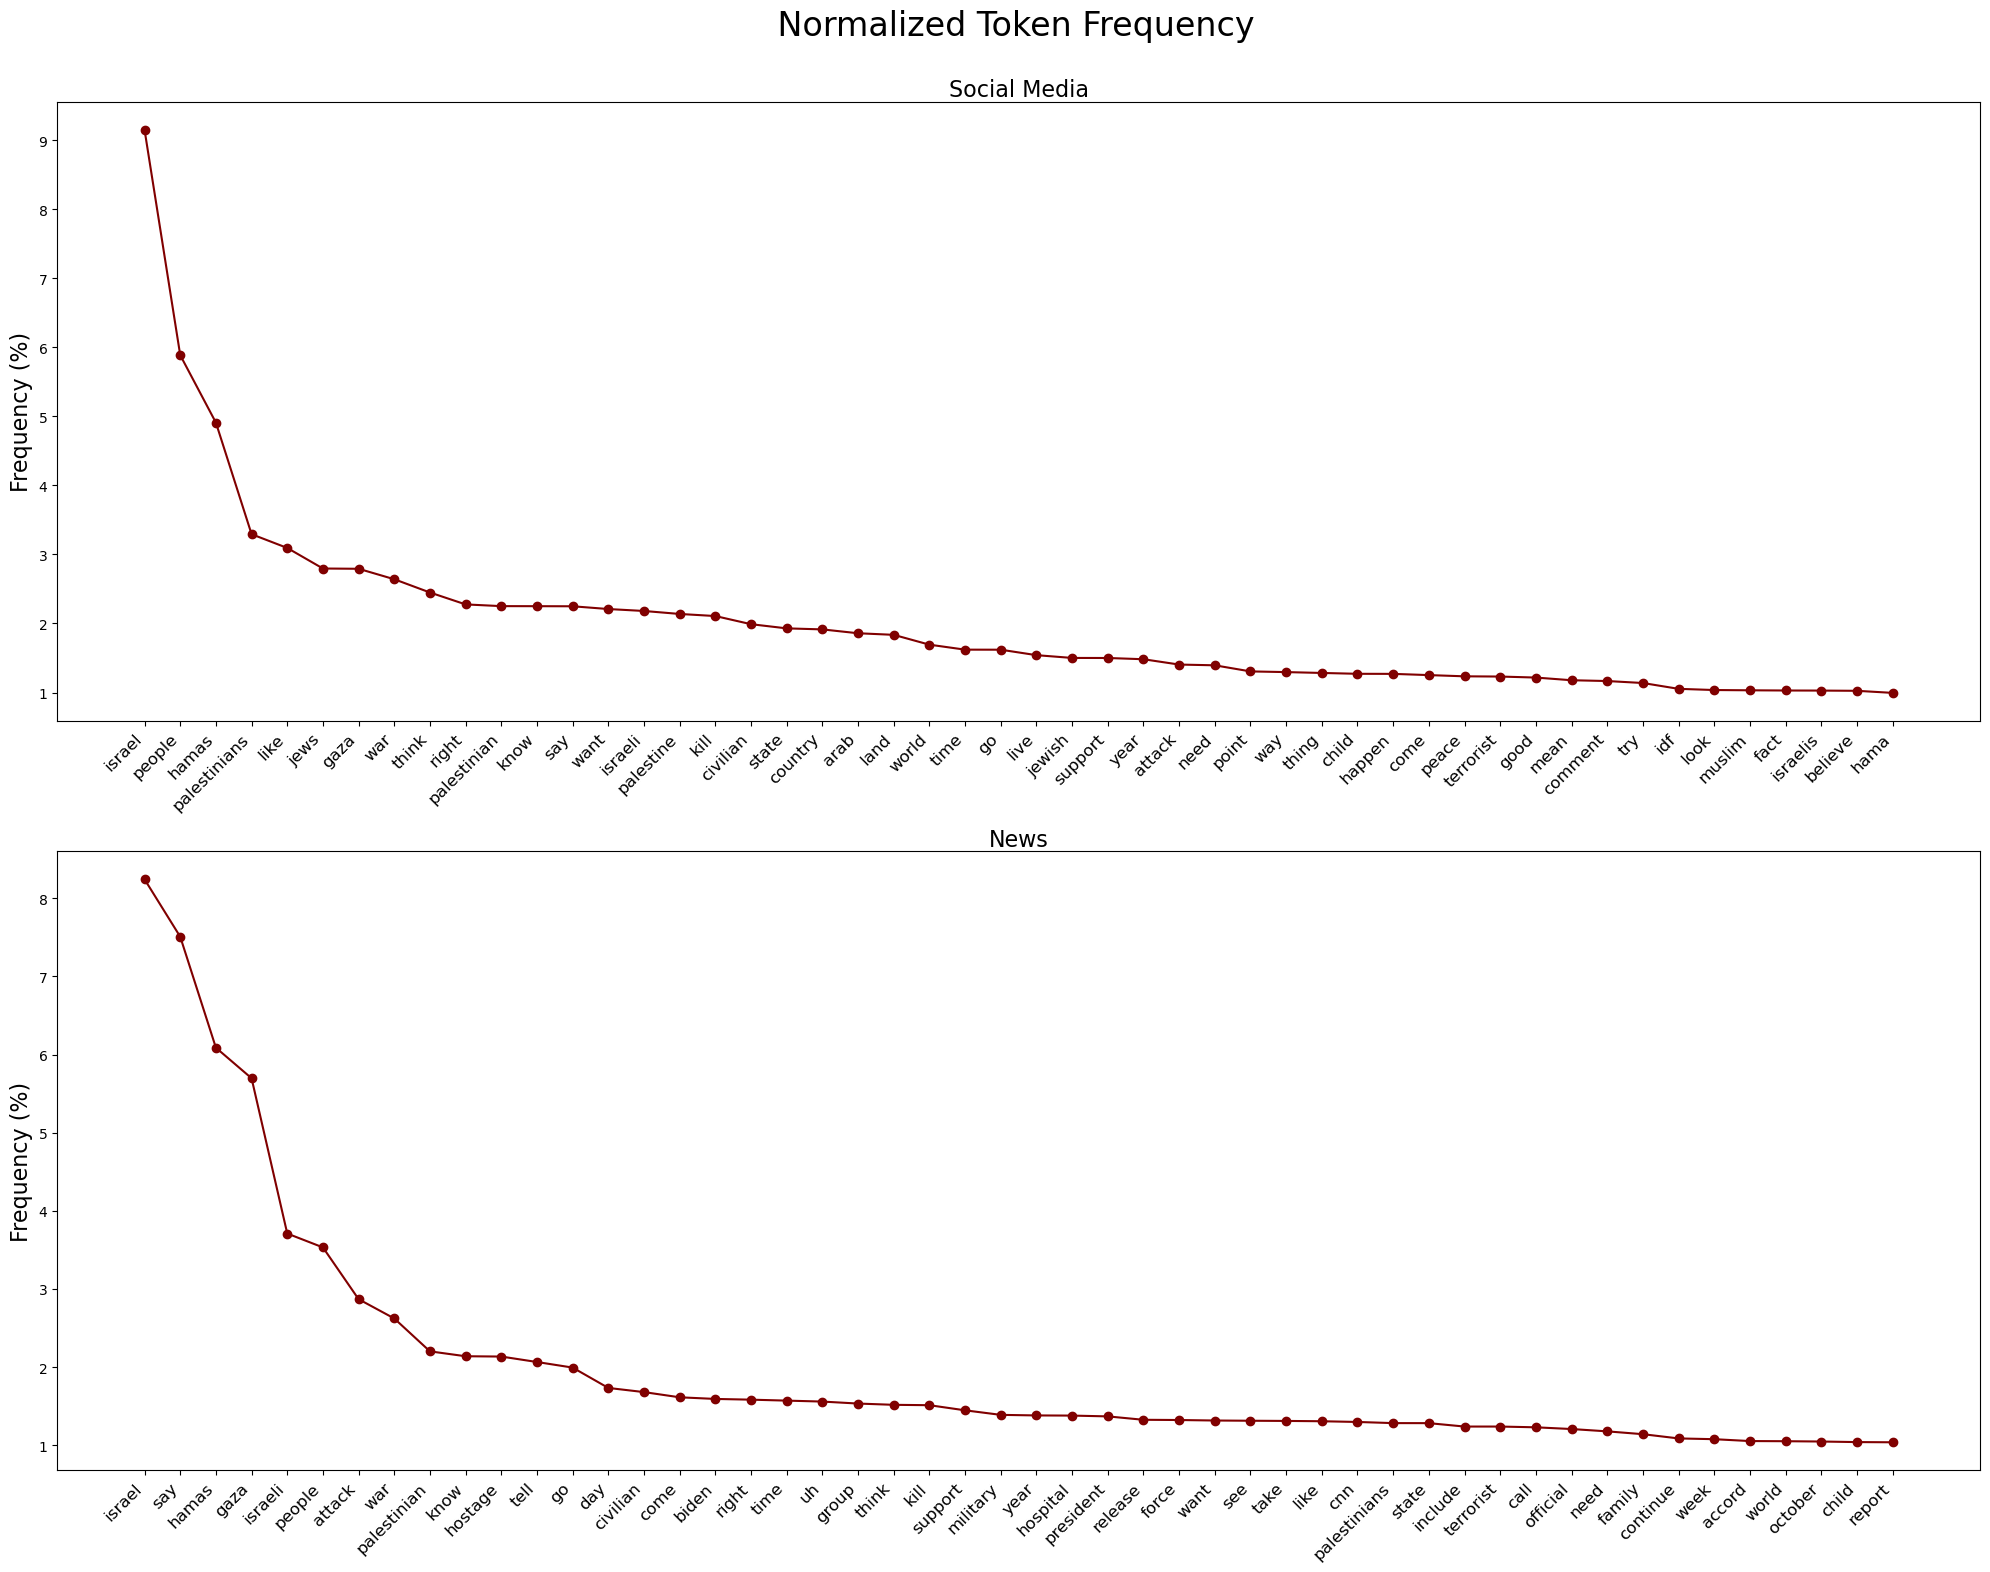

In [256]:
plot_freqs({"Social Media":all_sm_norm_non, "News":all_news_norm_non}, 50)

In [38]:
# FOR CONCORDANCE VIZ
all_sm_tokens = list(all_sm.toke_text.explode().dropna())
all_sm_Text = nltk.Text(all_sm_tokens)
all_sm_index = nltk.text.ConcordanceIndex(all_sm_Text)

all_news_tokens = list(all_news.toke_text.explode().dropna())
all_news_Text = nltk.Text(all_news_tokens)
all_news_index = nltk.text.ConcordanceIndex(all_news_Text)

In [39]:
# Palestine Concordance
all_sm_index.print_concordance('palestine', width=60, lines=15)
all_news_index.print_concordance('palestine', width=60, lines=15)

Displaying 15 of 21087 matches:
ove peace and respect to palestine no words so sorry ca nt 
ith leader of israel and palestine and hear all evidence of
hannel 10 ceasefire free palestine a live game of start end
gal brutal occupation of palestine i am ashtonish that west
gally oppressed occupied palestine be responsible get casua
ove peace and respect to palestine may allah rectify the af
 their captors i support palestine peoples thank you to eve
p genocide in gaza strip palestine i and millions of us wan
s of greater isreal free palestine why the world expecting 
made president of a free palestine child killers back in ac
ho cares about lala free palestine which of the palestinian
re about terrorists free palestine i would not be surprised
ar comparing ukraine and palestine are two different worlds
months ago my allah help palestine ameen allah bless palest
estine ameen allah bless palestine free palestine lanallahu
Displaying 15 of 917 matches:
 of people in support of palestine but

In [40]:
# Israel Concordance
all_sm_index.print_concordance('israel', width=60, lines=15)
all_news_index.print_concordance('israel', width=60, lines=15)

Displaying 15 of 89329 matches:
sit in room with leader of israel and palestine and hear all
upernova music festival in israel had cell phones with camer
 result of the creation of israel munafiq leader do not anyt
er of human rights how can israel explain these atrocities h
ort these horrors how does israel explain their atrocious be
ey are in more danger from israel than from their captors i 
ase talk about the weapons israel is using in gaza the deple
ulation that joe biden has israel is best interest in mind 6
everal family members when israel bombed st porphyrios of ga
wo months the usa zionists israel and idf have been fighting
 many countries this s not israel any more hamas beat israel
israel any more hamas beat israel october 7 but now is hamas
ey are nolonger welcome in israel no worries the us will con
ue to gift apartheid state israel billions it is official no
er get jobs done god bless israel not all people are idiots 
Displaying 15 of 15488 matches:
 getting some lines o

In [244]:
all_sm_norm_non

NameError: name 'all_sm_norm_non' is not defined

##### Find the Number of Words used in Social Media and News Sources

In [42]:
print("SM words:", all_sm.toke_text.explode().dropna().reset_index(drop=True).size)
print("SM unique words:", len(all_sm.toke_text.explode().dropna().reset_index(drop=True).unique()))
print("SM Vocab Density:", round(len(all_sm.toke_text.explode().dropna().reset_index(drop=True).unique()) / 
                                 all_sm.toke_text.explode().dropna().reset_index(drop=True).size, 3))
print("News words:", all_news.toke_text.explode().dropna().reset_index(drop=True).size)
print("News unique words:", len(all_news.toke_text.explode().dropna().reset_index(drop=True).unique()))
print("News  Vocab Density:", round(len(all_news.toke_text.explode().dropna().reset_index(drop=True).unique()) / 
                                    all_news.toke_text.explode().dropna().reset_index(drop=True).size, 3))

SM words: 10214501
SM unique words: 100391
SM Vocab Density: 0.01
News words: 2030953
News unique words: 35797
News  Vocab Density: 0.018


In [43]:
print("SM normalized words:", all_sm_norm_non.size)
print("SM normalized unique words:", len(all_sm_norm_non.unique()))
print("SM normalized Vocab Density:", round(len(all_sm_norm_non.unique()) / all_sm_norm_non.size,3))

print("News normalized words:", all_news_norm_non.size)
print("News normalized unique words:", len(all_news_norm_non.unique()))
print("News normalized Vocab Density:", round(len(all_news_norm_non.unique()) / all_news_norm_non.size,3))

SM normalized words: 4467479
SM normalized unique words: 84481
SM normalized Vocab Density: 0.019
News normalized words: 245340
News normalized unique words: 13512
News normalized Vocab Density: 0.055


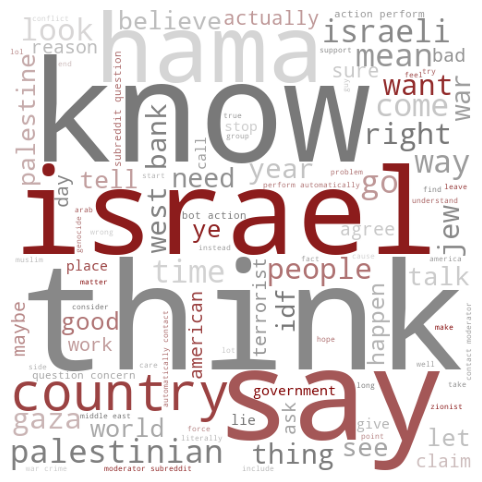

In [44]:
# Create a WordCloud object with specified parameters
# for Social Media
wc = wordcloud.WordCloud(background_color="white", max_words=100, width=1000,
                         colormap=cmap,height=1000, mode='RGBA', scale=.5
                         ).generate(' '.join(all_sm_norm_non))

plt.figure(figsize=(6, 6))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [56]:
print("israel" in all_sm_norm_non.value_counts().head(50))
print("palestine" in all_sm_norm_non.value_counts().head(50))

True
False


From the above we see that for news media, Israel received much more attention than Palestine

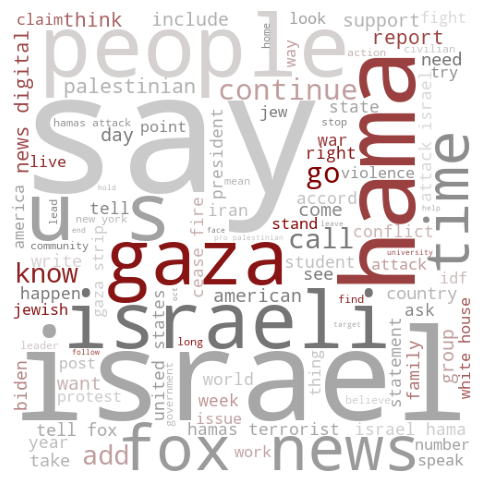

In [71]:
# WORD CLOUD for News

# Create a WordCloud object with specified parameters
wc = wordcloud.WordCloud(background_color="white", max_words=100, width=1000,
                         colormap=cmap,height=1000, mode='RGBA', scale=.5
                         ).generate(' '.join(all_news_norm_non))

plt.figure(figsize=(10, 6))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [72]:
print("israel" in all_news_norm_non.value_counts().head(100))
print("palestine" in all_news_norm_non.value_counts().head(100))

True
True


In [67]:
# cond Freq Dist for all POS tags
all_sm_cfdist_POS = nltk.ConditionalFreqDist((p, w) for w, p in sm_POS_no_stops)
all_news_cfdist_POS = nltk.ConditionalFreqDist((p, w) for w, p in news_POS_no_stops)

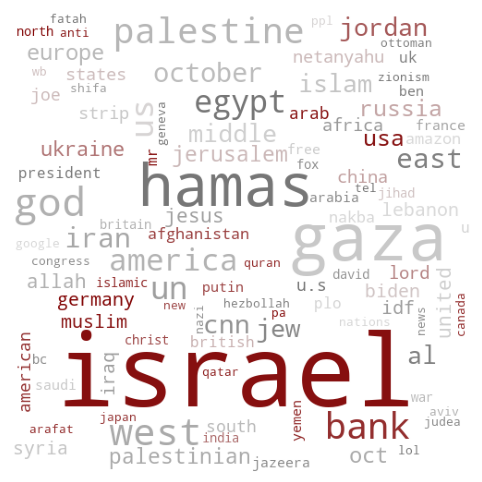

In [66]:
# SOCIAL MEDIA
# word cloud for proper nouns
wc = wordcloud.WordCloud(width=1000, height=1000, max_words=100,
                                colormap=cmap, background_color='white', 
                                mode='RGBA', scale=.5
                                ).generate_from_frequencies(all_sm_cfdist_POS["NNP"])
# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wc)
plt.axis('off')
plt.show()

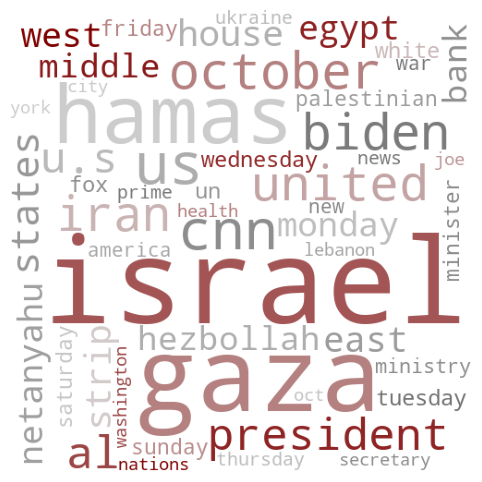

In [69]:
# NEWS
# word cloud for proper nouns
wc = wordcloud.WordCloud(width=1000, height=1000, max_words=50,
                                colormap=cmap, background_color='white', 
                                mode='RGBA', scale=.5
                                ).generate_from_frequencies(all_news_cfdist_POS["NNP"])
# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wc)
plt.axis('off')
plt.show()

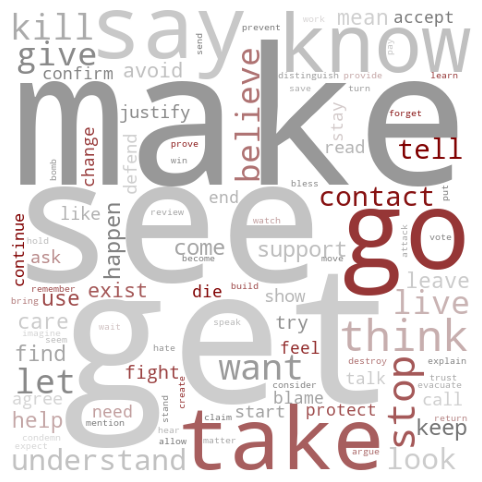

In [81]:
# verbs for social media
# word cloud for proper nouns
wc = wordcloud.WordCloud(width=1000, height=1000, max_words=100,
                         colormap=cmap,background_color='white', mode='RGBA', 
                         scale=.5).generate_from_frequencies(all_sm_cfdist_POS["VB"])

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wc)
plt.axis('off')
plt.show()

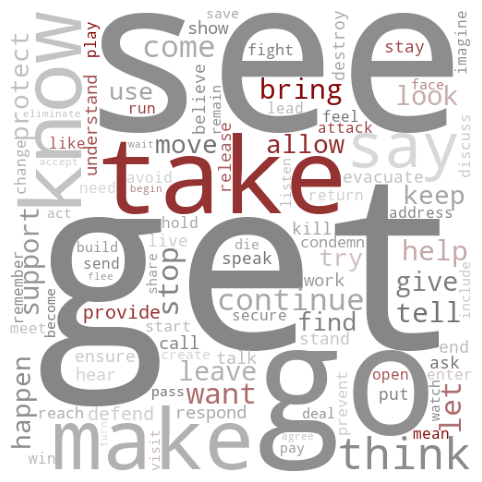

In [83]:
# verbs for news media
# word cloud for proper nouns
wc = wordcloud.WordCloud(width=1000, height=1000, max_words=100,
                         colormap=cmap,background_color='white', mode='RGBA', 
                         scale=.5).generate_from_frequencies(all_news_cfdist_POS["VB"])

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wc)
plt.axis('off')
plt.show()

#### word to vec viz

In [ ]:
targetWords = social_media_model.wv.index_to_key[:75]

# create a submatrix
wordsSubMatrix = []
for word in targetWords:
    wordsSubMatrix.append(social_media_model.wv[word])
wordsSubMatrix = np.array(wordsSubMatrix)
wordsSubMatrix


pcaWords = sklearn.decomposition.PCA(n_components = 75).fit(wordsSubMatrix)
reducedPCA_data = pcaWords.transform(wordsSubMatrix)
#T-SNE is theoretically better, but you should experiment
tsneWords = sklearn.manifold.TSNE(n_components = 2).fit_transform(reducedPCA_data)

In [ ]:
pcaWords = sklearn.decomposition.PCA(n_components = 75,random_state=42).fit_transform(wordsSubMatrix)

fig = plt.figure(figsize = (10,6))
ax = fig.add_subplot(111)

plt.scatter(pcaWords[:, 0], pcaWords[:, 1], alpha=0.5, color="#737373")
for i, word in enumerate(targetWords):
    plt.annotate(word, (pcaWords[:, 0][i], pcaWords[:, 1][i]), 
                 size=20 * (100 - i) / 100, color="#800000", alpha=0.75)

plt.xticks(())
plt.yticks(())

plt.axis('off')
plt.show()

In [ ]:
tsneWords = sklearn.manifold.TSNE(n_components = 2, random_state=69).fit_transform(wordsSubMatrix)

# lets plot the top 50 words
fig = plt.figure(figsize = (10,6))
ax = fig.add_subplot(111)

plt.scatter(tsneWords[:, 0], tsneWords[:, 1], alpha=0.5, color="#737373")
for i, word in enumerate(targetWords):
    plt.annotate(word, (tsneWords[:, 0][i],tsneWords[:, 1][i]), 
                 size =  20 * (100 - i) / 100, color="#800000", alpha=0.75)

plt.xticks(())
plt.yticks(())
plt.axis('off')
plt.show()